# 13 — Jev as router: a typed decision model chooses the LLM

The LLM integration POC is complete. This notebook starts the next
integration: **non-traditional AI models** — specifically TypeSafe AI's
**Jev** (System One), a model that returns fast, structured, typed decisions
with probabilities instead of generated text.

Jev enters the multi-LLM loop as the **router**: each step, the controller
gives Jev the query, the materialized memory and the current soft state
(BSS), and asks one typed question:

```text
Which LLM should answer this query?
  llm_a — DeepSeek reasoning distill (longer, structured)
  llm_b — Qwen2.5 instruct (general, factual)
  llm_c — gpt2 (tiny, fast, short)
```

Jev answers with `choice + probabilities + confidence`; only the chosen LLM
generates; ewm-sm ingests the answer unchanged. The decision is logged as a
`DecisionRecord` — the first non-LLM actor in the loop.

When `TYPESAFE_API_KEY` is not set, the `JevAdapter` falls back to a
deterministic mock with the same typed shape, so the notebook runs
end-to-end; set the key to use the real model.

In [1]:
import os, sys

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import (
    EwmScene,
    JevAdapter,
    LlmAdapter,
    run_open_loop,
    run_jev_loop,
)

WORK = "/home/alexmy/.cache/ewm-multi-llm-jev"
os.makedirs(WORK, exist_ok=True)
ewm = EwmScene()
print("ewm-scene:", ewm.bin)
print("work:", WORK)

ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
work: /home/alexmy/.cache/ewm-multi-llm-jev


In [2]:
QUERIES = [
    "What is the capital of France?",
    "Explain gravity in one sentence.",
    "Write a haiku about rain.",
    "What is the meaning of life?",
    "Name three planets in our solar system.",
    "What is the speed of light?",
    "Define entropy in simple words.",
    "Who wrote Romeo and Juliet?",
]

adapter = LlmAdapter()                    # the three real small LLMs
jev = JevAdapter()                        # real Jev if TYPESAFE_API_KEY is set
print("adapter names:", adapter.names)
print("Jev mode:", "mock" if jev.mock else "real API", "| reason:", jev._mock_reason)

adapter names: ('llm_a', 'llm_b', 'llm_c')
Jev mode: mock | reason: TYPESAFE_API_KEY not set


## §1 — Open loop: the shared context

The Pavlov cycle builds the per-LLM frame and prototypes the router will
read — same apparatus as notebooks 09–12.

In [3]:
open_result = run_open_loop(adapter, ewm, QUERIES, WORK, cycles=3, max_new_tokens=48)
print("IICA (union discovered twice):", open_result.same_union)
print("BSS trajectory:", open_result.M_ol.shape, "| prototypes:", open_result.M_proto.shape)
print("DFT-detected period:", open_result.period, "steps (true period 8)")

IICA (union discovered twice): True
BSS trajectory: (24, 3) | prototypes: (8, 3)
DFT-detected period: 8.0 steps (true period 8)


## §2 — Jev routing loop

16 steps. Each step: build the decision state (query + materialized memory +
current BSS), ask Jev, route to the chosen LLM, ingest the answer, log the
decision.

In [4]:
jev_result = run_jev_loop(
    adapter, jev, ewm, open_result, QUERIES, WORK, T=16, max_new_tokens=48
)

decisions = jev_result.decision_log
print()
print("decision distribution:")
for name in adapter.names:
    n = sum(1 for d in decisions if d.decision == name)
    print(f"  {name:6s} {n:2d} steps")
print("mean confidence:", round(float(np.mean([d.confidence for d in decisions])), 3))
print("mock mode:", all(d.mock for d in decisions))

t= 0 q=0  route=llm_a   confidence=0.476  gated=False  mock=True
t= 4 q=4  route=llm_c   confidence=0.451  gated=False  mock=True
t= 8 q=0  route=llm_c   confidence=0.423  gated=False  mock=True
t=12 q=4  route=llm_a   confidence=0.438  gated=False  mock=True
t=15 q=7  route=llm_b   confidence=0.353  gated=False  mock=True

decision distribution:
  llm_a   4 steps
  llm_b   6 steps
  llm_c   6 steps
mean confidence: 0.422
mock mode: True


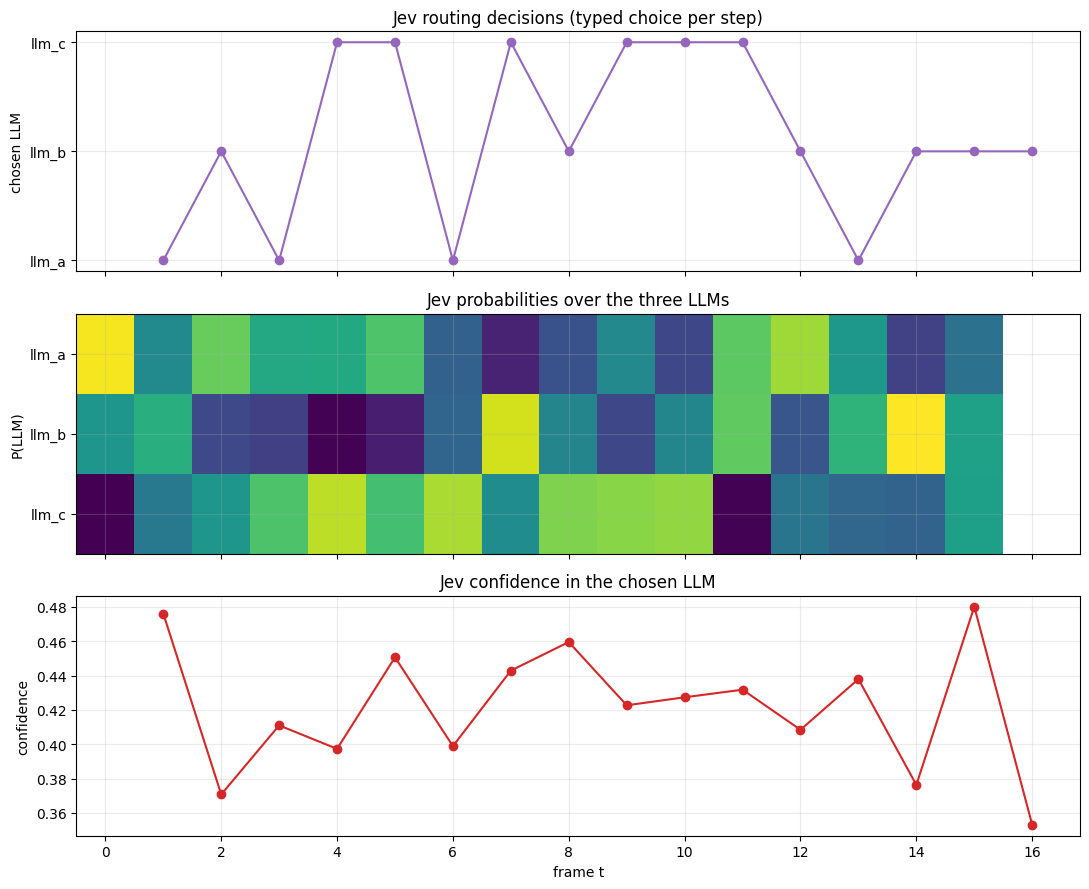

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

names = list(adapter.names)
T = len(decisions)
t_axis = np.arange(1, T + 1)
route_idx = [names.index(d.decision) for d in decisions]
conf = [d.confidence for d in decisions]
P = np.array([[d.probabilities.get(n, 0.0) for n in names] for d in decisions])

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(t_axis, route_idx, "o-", color="tab:purple")
axes[0].set_yticks(range(len(names)), names)
axes[0].set_ylabel("chosen LLM")
axes[0].set_title("Jev routing decisions (typed choice per step)")
axes[0].grid(alpha=0.25)

axes[1].imshow(P.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[1].set_yticks(range(len(names)), names)
axes[1].set_ylabel("P(LLM)")
axes[1].set_title("Jev probabilities over the three LLMs")
axes[1].grid(alpha=0.25)

axes[2].plot(t_axis, conf, "o-", color="tab:red")
axes[2].set_ylabel("confidence")
axes[2].set_xlabel("frame t")
axes[2].set_title("Jev confidence in the chosen LLM")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/jev_router.png", dpi=110)
plt.show()

## Summary

- Jev entered the loop as a **typed-decision adapter**: `state + typed
  question → choice + probabilities + confidence`, then only the chosen LLM
  generated. ewm-sm ran the same commands as always (`pyramid`, `ingest`,
  `project`, `materialize`).
- The decision itself is logged as a `DecisionRecord` in the trajectory —
  the first non-LLM actor in the system state.
- With `TYPESAFE_API_KEY` set, the same notebook uses the real System One
  model (70–500 ms, structured output guaranteed by construction); without
  it, the deterministic mock keeps the loop executable.

Next: ingest Jev's decision record as a first-class probe so the decision
becomes part of `S(t)`, and use Jev for the other two primitives (`Score`,
`Noul`) to gate confidence per action.